In [1]:
import pandas as pd
import numpy as np

# Importacion de Datos recuperados de LOKI

In [2]:
df = pd.read_csv("../datasets/01_logs_dataset.csv")
df.head()

,@timestamp,service,level,event_type,outcome,http_method,http_uri,http_status,duration_ms,error_type,error_message,error_origin,traceId
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/register,201.0,363.0,NaN,NaN,NaN,6a476cca227cf2c2a7778eea6814c767
1,2026-07-03T08:04:56.876Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,115.0,NaN,NaN,NaN,6a476d28bef605f56445e5f31a75ab8a
2,2026-07-03T08:04:59.767Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,108.0,NaN,NaN,NaN,6a476d2b308ea5cc0f8932e9de3ca02d
3,2026-07-03T08:05:04.616Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,107.0,NaN,NaN,NaN,6a476d30b15c719121fc2c7488b11b02
4,2026-07-03T08:05:06.940Z,api-autenticacion,INFO,HTTP_REQUEST,SUCCESS,POST,/api/auth/login,200.0,87.0,NaN,NaN,NaN,6a476d323360f89f718e7343d5f6686b


In [3]:
print(f"Total de registros: {len(df)}")
print(f"\nColumnas disponibles:\n{df.columns.tolist()}")
print(f"\nDistribución de event_type:\n{df['event_type'].value_counts()}")
print(f"\nDistribución de level:\n{df['level'].value_counts()}")
print(f"\nDistribución de service:\n{df['service'].value_counts()}")
print(f"\nValores nulos por columna:\n{df.isnull().sum()}")

Total de registros: 4970

Columnas disponibles:
['@timestamp', 'service', 'level', 'event_type', 'outcome', 'http_method', 'http_uri', 'http_status', 'duration_ms', 'error_type', 'error_message', 'error_origin', 'traceId']

Distribución de event_type:
event_type
HTTP_REQUEST       1145
UNHANDLED_ERROR    1115
SERVER_ERROR        966
Name: count, dtype: int64

Distribución de level:
level
ERROR    2389
WARN     1349
INFO     1232
Name: count, dtype: int64

Distribución de service:
service
api-inventario       3081
api-pedidos          1834
api-autenticacion      55
Name: count, dtype: int64

Valores nulos por columna:
@timestamp          0
service             0
level               0
event_type       1744
outcome          2859
http_method      2859
http_uri         2859
http_status      2859
duration_ms      2859
error_type       3855
error_message    4051
error_origin     4465
traceId            98
dtype: int64


## Documentacion sobre los datos
- *event_type, service, http_metos*: Son datos ordinales. Nos indican el tipo de peticion. Usarmeos OnehotEncoder
- *duration_ms, http_status*: Valores numericos que se pueden utilizar de entrada. Podria usarse StandardScaler para mejorar la precision final
- *@timestamp*: De tipo temporal. Requiere de un procesamiento donde vamos a sacar varias columnas: hour_of_day, day_of_week, minute_of_hour
- *level*: es de categoria ordinal, es decir, Warn, Info y Error, tendrán pesos diferentes e indicaran diferentes grados, en este caso, de gravedad. Por lo tanto se mapearan a 0, 1, 2 para que el modelo comprenda que contienen diferentes importancias
- *error_message, error_origin*: Serán tratados por un NLP en un futuro.
- *outcome*: Aporta redundancia al dataset, ya tenemos http_status para que el modelo pueda detectar si la operacion ha salido correctaamente o de manera fallida. Se elimina
- *traceId*: Cambiante para cada transaccion, el modelo tenderia a memorizar. Esta variable se eleminar porque confundiria al modelo

# Limpieza de valores nulos y anomalías

In [4]:
def nulos(df):
    nulos = df.isna().sum()
    columnas_nulas = nulos[nulos>0]
    print(columnas_nulas.sort_values(ascending=False))

In [5]:
# NO elimino traceId ni error_origin porque me va a servir para mezclar los dos logs que me dan entre si
df = df.drop(columns=["error_message", "outcome"])

In [6]:
# Elimina filas donde event_type, http_uri y duration_ms son todos nulos
df = df.dropna(subset=["event_type", "http_uri", "duration_ms"], how="all")

# Elimina también los endpoints de caos
df = df[~df["http_uri"].str.contains("/chaos/", na=False)]

In [7]:
nulos(df)

error_origin    2139
error_type      1529
http_method     1115
http_uri        1115
http_status     1115
duration_ms     1115
dtype: int64


- *duration_ms*: sacar la media puede ser peligroso, por lo que decido actuar con la media
- *error_type*: cambiar a NONE aquellas que estan en NAN para conseguir que el modelo entienda que no hay errores cuando es sucess

In [8]:
salidas_error = df[df["http_status"] != 200]
salidas_error

,@timestamp,service,level,event_type,http_method,http_uri,http_status,duration_ms,error_type,error_origin,traceId
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/register,201.0,363.0,NaN,NaN,6a476cca227cf2c2a7778eea6814c767
807,2026-07-03T08:05:35.850Z,api-inventario,ERROR,SERVER_ERROR,GET,/inventario,500.0,30060.0,NaN,NaN,6a476d3147869f889d92defc1f2c96fe
808,2026-07-03T08:05:36.720Z,api-inventario,ERROR,SERVER_ERROR,POST,/inventario/1/retirar,500.0,30023.0,NaN,NaN,6a476d328b5403ed9dcd89454f2cfbc4
809,2026-07-03T08:05:36.850Z,api-inventario,ERROR,SERVER_ERROR,GET,/inventario/1,500.0,30015.0,NaN,NaN,6a476d3242caf70754e9311c31d05f11
810,2026-07-03T08:05:38.000Z,api-inventario,ERROR,SERVER_ERROR,POST,/inventario/1/retirar,500.0,30010.0,NaN,NaN,6a476d33ea44f52ae9322e42e9b06264
...,...,...,...,...,...,...,...,...,...,...,...
4514,2026-07-03T08:40:52.589Z,api-pedidos,ERROR,UNHANDLED_ERROR,NaN,NaN,NaN,NaN,ResourceAccessException,PedidoService.retirarStockeDeInventario(Pedido...,6a47758ffac02a9e4213db9585b587a7
4515,2026-07-03T08:40:52.702Z,api-pedidos,ERROR,UNHANDLED_ERROR,NaN,NaN,NaN,NaN,ResourceAccessException,PedidoService.retirarStockeDeInventario(Pedido...,6a47758f0ede2cc79bdcd4b0f2711f8d
4516,2026-07-03T08:40:58.349Z,api-pedidos,ERROR,UNHANDLED_ERROR,NaN,NaN,NaN,NaN,RuntimeException,ChaosController.error(ChaosController.java:82)...,6a47759ac84ad1dfa303fc5d18365e3c
4517,2026-07-03T08:40:58.707Z,api-pedidos,ERROR,UNHANDLED_ERROR,NaN,NaN,NaN,NaN,RuntimeException,ChaosController.error(ChaosController.java:82)...,6a47759a9547aa2724469fc879a9c70f


In [9]:
df["duration_ms"] = df["duration_ms"].fillna(df["duration_ms"].median())
df["error_type"] = df["error_type"].fillna("NONE")
df["http_method"] = df["http_method"].fillna("UNKNOWN")
df["http_uri"] = df["http_uri"].fillna("UNKNOWN")
df["http_status"] = df["http_status"].fillna(0)

In [10]:
df

,@timestamp,service,level,event_type,http_method,http_uri,http_status,duration_ms,error_type,error_origin,traceId
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/register,201.0,363.0,NONE,NaN,6a476cca227cf2c2a7778eea6814c767
1,2026-07-03T08:04:56.876Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,115.0,NONE,NaN,6a476d28bef605f56445e5f31a75ab8a
2,2026-07-03T08:04:59.767Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,108.0,NONE,NaN,6a476d2b308ea5cc0f8932e9de3ca02d
3,2026-07-03T08:05:04.616Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,107.0,NONE,NaN,6a476d30b15c719121fc2c7488b11b02
4,2026-07-03T08:05:06.940Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,87.0,NONE,NaN,6a476d323360f89f718e7343d5f6686b
...,...,...,...,...,...,...,...,...,...,...,...
4514,2026-07-03T08:40:52.589Z,api-pedidos,ERROR,UNHANDLED_ERROR,UNKNOWN,UNKNOWN,0.0,5167.0,ResourceAccessException,PedidoService.retirarStockeDeInventario(Pedido...,6a47758ffac02a9e4213db9585b587a7
4515,2026-07-03T08:40:52.702Z,api-pedidos,ERROR,UNHANDLED_ERROR,UNKNOWN,UNKNOWN,0.0,5167.0,ResourceAccessException,PedidoService.retirarStockeDeInventario(Pedido...,6a47758f0ede2cc79bdcd4b0f2711f8d
4516,2026-07-03T08:40:58.349Z,api-pedidos,ERROR,UNHANDLED_ERROR,UNKNOWN,UNKNOWN,0.0,5167.0,RuntimeException,ChaosController.error(ChaosController.java:82)...,6a47759ac84ad1dfa303fc5d18365e3c
4517,2026-07-03T08:40:58.707Z,api-pedidos,ERROR,UNHANDLED_ERROR,UNKNOWN,UNKNOWN,0.0,5167.0,RuntimeException,ChaosController.error(ChaosController.java:82)...,6a47759a9547aa2724469fc879a9c70f


In [11]:
# Logs del filtro HTTP
filtro = df[df["http_uri"] != "UNKNOWN"].copy()

# Logs de error
errores = df[df["error_type"] != "NONE"][["traceId", "error_type", "error_origin"]].copy()

# Une por traceId — una fila por petición con toda la información
df_completo = filtro.merge(errores, on="traceId", how="left")
df_completo = df_completo.rename(columns={"error_type_x": "error_type"})
cdf = df_completo.drop(columns=["error_origin_x", "error_origin_y", "error_type_y"])
print(f"Dataset unificado: {len(df_completo)} filas")

Dataset unificado: 2057 filas


In [12]:
cdf.head()

,@timestamp,service,level,event_type,http_method,http_uri,http_status,duration_ms,error_type,traceId
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/register,201.0,363.0,NONE,6a476cca227cf2c2a7778eea6814c767
1,2026-07-03T08:04:56.876Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,115.0,NONE,6a476d28bef605f56445e5f31a75ab8a
2,2026-07-03T08:04:59.767Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,108.0,NONE,6a476d2b308ea5cc0f8932e9de3ca02d
3,2026-07-03T08:05:04.616Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,107.0,NONE,6a476d30b15c719121fc2c7488b11b02
4,2026-07-03T08:05:06.940Z,api-autenticacion,INFO,HTTP_REQUEST,POST,/api/auth/login,200.0,87.0,NONE,6a476d323360f89f718e7343d5f6686b


In [13]:
print("Nulos:")
nulos(cdf)
print("=============")
print(f"Numero de filas que son errores: {len(errores)}")
print(f"Numero de filas totales {len(cdf)}")

Nulos:
Series([], dtype: int64)
Numero de filas que son errores: 1115
Numero de filas totales 2057


In [14]:
def uri_a_servicio_destino(uri):
    if "/inventario" in uri:    return "inventario"
    if "/pedidos" in uri:       return "pedidos"
    if "/auth" in uri:          return "autenticacion"
    return "unknown"

cdf["uri_servicio"] = cdf["http_uri"].apply(uri_a_servicio_destino)
cdf = cdf.drop(columns=["http_uri"])
print(cdf["uri_servicio"].value_counts())
cdf.head()

uri_servicio
inventario       1174
pedidos           862
autenticacion      21
Name: count, dtype: int64


,@timestamp,service,level,event_type,http_method,http_status,duration_ms,error_type,traceId,uri_servicio
0,2026-07-03T08:03:23.032Z,api-autenticacion,INFO,HTTP_REQUEST,POST,201.0,363.0,NONE,6a476cca227cf2c2a7778eea6814c767,autenticacion
1,2026-07-03T08:04:56.876Z,api-autenticacion,INFO,HTTP_REQUEST,POST,200.0,115.0,NONE,6a476d28bef605f56445e5f31a75ab8a,autenticacion
2,2026-07-03T08:04:59.767Z,api-autenticacion,INFO,HTTP_REQUEST,POST,200.0,108.0,NONE,6a476d2b308ea5cc0f8932e9de3ca02d,autenticacion
3,2026-07-03T08:05:04.616Z,api-autenticacion,INFO,HTTP_REQUEST,POST,200.0,107.0,NONE,6a476d30b15c719121fc2c7488b11b02,autenticacion
4,2026-07-03T08:05:06.940Z,api-autenticacion,INFO,HTTP_REQUEST,POST,200.0,87.0,NONE,6a476d323360f89f718e7343d5f6686b,autenticacion


## Transformacion de datos y escalado

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder

# event_type, service, http_metod -> one hot encoding
categorical_scaler = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='constant', fill_value='NONE')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# duration_ms, http_status -> Standar scaler
num_scaler = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# level -> OrdinalEncodera
level_pipeline = Pipeline(steps=[
    ('inputer', SimpleImputer(strategy='constant',fill_value='INFO')),
    ('ordinal', OrdinalEncoder(categories=[["INFO", "WARN", "ERROR"]]))
])


# Clase para descpomponer timestamp
class TimestampDescomponedor(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        return self  
    
    def transform(self, X):
        # Convierte a Series independientemente de si llega como DataFrame, array o Series
        if hasattr(X, 'iloc'):
            # Es un DataFrame — coge la primera columna
            serie = pd.to_datetime(X.iloc[:, 0])
        else:
            # Es un array numpy
            serie = pd.to_datetime(pd.Series(X.ravel()))
        
        resultado = pd.DataFrame({
            "hour_of_day":    serie.dt.hour,
            "day_of_week":    serie.dt.dayofweek,
            "minute_of_hour": serie.dt.minute
        })
        
        return resultado.values
timestamp_pipeline = Pipeline(steps=[
    ("descomponedor", TimestampDescomponedor()),
    ("scaler", StandardScaler())
])

In [16]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_scaler, ["event_type", "service", "http_method", "uri_servicio"]),
    ("num", num_scaler, ["duration_ms", "http_status"]),
    ("ts", timestamp_pipeline, ["@timestamp"]),
    ("ord", level_pipeline, ["level"])
])

## Columna para Entrenamiento semisupervisadom

In [17]:
cdf["es_anomalia"] = (
    (cdf["level"] == "ERROR") |
    (cdf["event_type"].isin(["SERVER_ERROR", "UNHANDLED_ERROR"])) |
    (cdf["duration_ms"] > df["duration_ms"].quantile(0.95))
).astype(int)

# ISOLATION FOREST

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import make_scorer, f1_score

scoring = make_scorer(f1_score, pos_label=-1) # -1 es anomalia para isolation

X = cdf.drop(columns=["es_anomalia"])
y = cdf["es_anomalia"]
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

isolation_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", IsolationForest())
])

param_grid = {
    "model__n_estimators":  [50, 100, 200, 400, 600],
    "model__contamination": [0.05, 0.10, 0.15, 0.20],
    "model__max_samples":   ["auto", 0.5, 0.8],
    "model__max_features":  [0.5, 0.8, 1.0]
}

isolation_search = GridSearchCV(
    estimator=isolation_pipeline,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring=scoring
)

In [26]:
print(X_train.dtypes)

@timestamp          str
service             str
level               str
event_type          str
http_method         str
http_status     float64
duration_ms     float64
error_type          str
traceId             str
uri_servicio        str
dtype: object


In [27]:
import warnings

warnings.filterwarnings('ignore')

# ejecutamos el Grid
isolation_search.fit(X_train, y_train)

from sklearn.metrics import classification_report

predicciones = isolation_search.predict(X_test)
predicciones_binarias = (predicciones == -1).astype(int)
print(classification_report(y_test, predicciones_binarias, target_names=["normal", "anomalia"]))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
              precision    recall  f1-score   support

      normal       0.53      0.93      0.68       221
    anomalia       0.43      0.06      0.11       191

    accuracy                           0.53       412
   macro avg       0.48      0.50      0.39       412
weighted avg       0.49      0.53      0.41       412



In [ ]:
isolation_search

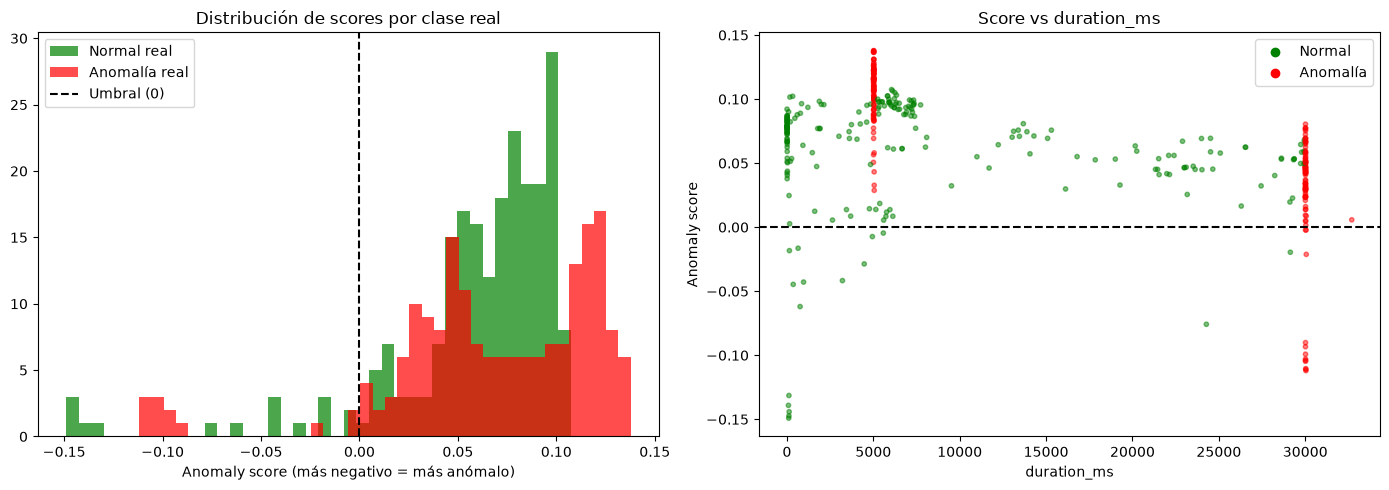


Top 10 logs más anómalos (score más negativo):
        event_type            service  duration_ms  http_status     score  real
20    HTTP_REQUEST  api-autenticacion        104.0        200.0 -0.149078     0
1     HTTP_REQUEST  api-autenticacion        115.0        200.0 -0.147302     0
14    HTTP_REQUEST  api-autenticacion        129.0        200.0 -0.144111     0
4     HTTP_REQUEST  api-autenticacion         87.0        200.0 -0.139108     0
13    HTTP_REQUEST  api-autenticacion        115.0        200.0 -0.131415     0
1578  SERVER_ERROR        api-pedidos      30042.0        500.0 -0.111973     1
1908  SERVER_ERROR        api-pedidos      30030.0        500.0 -0.111064     1
1862  SERVER_ERROR        api-pedidos      30031.0        500.0 -0.110459     1
1870  SERVER_ERROR        api-pedidos      30013.0        500.0 -0.104650     1
1872  SERVER_ERROR        api-pedidos      30023.0        500.0 -0.104105     1


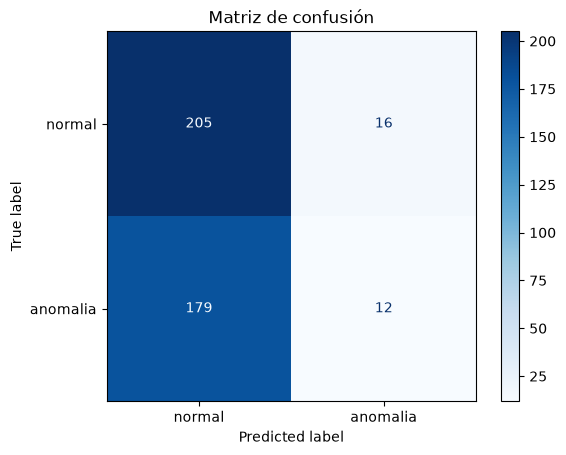

In [33]:
import matplotlib.pyplot as plt
# Scores de anomalía — cuanto más negativo, más anómalo
scores = isolation_search.decision_function(X_test)

# Añade los scores y las predicciones al DataFrame de test para inspeccionarlo
X_test_vis = X_test.copy()
X_test_vis["score"]            = scores
X_test_vis["prediccion"]       = predicciones_binarias
X_test_vis["real"]             = y_test.values

# ── Gráfico 1: distribución de scores ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de scores separado por clase real
normales  = scores[y_test.values == 0]
anomalias = scores[y_test.values == 1]

axes[0].hist(normales,  bins=40, alpha=0.7, color="green", label="Normal real")
axes[0].hist(anomalias, bins=40, alpha=0.7, color="red",   label="Anomalía real")
axes[0].axvline(x=0, color="black", linestyle="--", label="Umbral (0)")
axes[0].set_title("Distribución de scores por clase real")
axes[0].set_xlabel("Anomaly score (más negativo = más anómalo)")
axes[0].legend()

# ── Gráfico 2: score vs duration_ms ─────────────────────────────────────────
colores = ["green" if r == 0 else "red" for r in y_test.values]
axes[1].scatter(X_test["duration_ms"], scores, c=colores, alpha=0.5, s=10)
axes[1].axhline(y=0, color="black", linestyle="--", label="Umbral")
axes[1].set_title("Score vs duration_ms")
axes[1].set_xlabel("duration_ms")
axes[1].set_ylabel("Anomaly score")
axes[1].legend(handles=[
    plt.scatter([], [], color="green", label="Normal"),
    plt.scatter([], [], color="red",   label="Anomalía")
])

plt.tight_layout()
plt.show()

# ── Tabla: los 10 logs más anómalos detectados ───────────────────────────────
print("\nTop 10 logs más anómalos (score más negativo):")
top_anomalos = X_test_vis.nsmallest(10, "score")[
    ["event_type", "service", "duration_ms", "http_status", "score", "real"]
]
print(top_anomalos.to_string())

# ── Matriz de confusión visual ───────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, predicciones_binarias)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["normal", "anomalia"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()